# Cuaderno de clase
## Mecánica Celeste (2026-1) con Jorge I. Zuluaga
## Virial y tiempo de relajación

En este notebook pondremos en práctica algunos conceptos relacionados con el teorema del virial en el problema gravitacional de los N cuerpos.

## Importar paquetes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rebound as rb
import plotly.graph_objects as go

ModuleNotFoundError: No module named 'numpy'

Estamos trabajando en unidades canónicas:

In [29]:
G = 1

## Generación de un sistema aleatorio de N cuerpos

Vamos a generar las condiciones iniciales de un sistema de N-cuerpos:

In [30]:
# Número de partículas
N = 20

# Semilla de número aleatorios: cambiar para obtener diferentes condiciones iniciales
np.random.seed(3)

# Masas aleatorias uniformes en [0.5, 2], normalizadas a M_total = 1
masas = np.random.uniform(0.5, 2.0, N)
masas /= masas.sum()

# Posiciones uniformes en una esfera de radio R = 1
rcoords   = np.random.uniform(0, 1, N) ** (1/3)          # radio (vol. uniforme)
thetas   = np.arccos(1 - 2 * np.random.uniform(0, 1, N)) # ángulo polar
phis     = 2 * np.pi * np.random.uniform(0, 1, N)        # ángulo azimutal

# Ponemos todas las pocisiones un una matriz de forma (N, 3)
rinis = np.column_stack([
    rcoords * np.sin(thetas) * np.cos(phis),
    rcoords * np.sin(thetas) * np.sin(phis),
    rcoords * np.cos(thetas)
])

# Velocidades iniciales
vinis = np.random.normal(0, 1, (N, 3)) # Componentes de velocidad normales con media 0 y desviación estándar 1

# Calculamos la velocidad del centro de masa
VCM = np.average(vinis, axis=0, weights=masas)

# Eliminamos el movimiento del centro de masa
vinis -= VCM

Simulemos el sistema con REBOUND:

In [31]:
def simula_ncuerpos_rebound(masas, rinis, vinis, T, Nt):
    n = len(masas)
    sim = rb.Simulation()
    for i in range(n):
        sim.add(m=masas[i],
                x=rinis[i, 0], y=rinis[i, 1], z=rinis[i, 2],
                vx=vinis[i, 0], vy=vinis[i, 1], vz=vinis[i, 2])
    sim.move_to_com()

    # Tiempo todal de integración
    ts = np.linspace(0, T, Nt)

    # Cubo para el almacenamiento de las posiciones
    rps = np.zeros((n, Nt, 3))
    vps = np.zeros((n, Nt, 3))

    for k, t in enumerate(ts):
        sim.integrate(t)
        for j in range(n):
            rps[j, k] = sim.particles[j].xyz
            vps[j, k] = sim.particles[j].vxyz

    return rps, vps

Usa la rutina para simular el sistema:

In [32]:
# Simular el sistema con T = 10 unidades de tiempo y 100 pasos

rps, vps = simula_ncuerpos_rebound(masas, rinis, vinis, T=10, Nt=1000)
rps, vps


(array([[[ -0.31299798,   0.3633828 ,   0.08907016],
         [ -0.31259119,   0.3522408 ,   0.09399413],
         [ -0.31210424,   0.34117276,   0.09893145],
         ...,
         [  4.86591614,  -7.54023748,   1.01848204],
         [  4.87110732,  -7.54702698,   1.01905195],
         [  4.87629833,  -7.55381601,   1.0196218 ]],
 
        [[ -0.29525538,  -0.865942  ,   0.02122253],
         [ -0.27699363,  -0.87670167,   0.03076215],
         [ -0.25868512,  -0.88740581,   0.04031125],
         ...,
         [ 12.33146326,   0.31209053,   2.54270643],
         [ 12.34310479,   0.31361203,   2.54497282],
         [ 12.35474586,   0.31513348,   2.54723907]],
 
        [[ -0.22181381,   0.47328606,   0.31740227],
         [ -0.22452009,   0.49045256,   0.3226964 ],
         [ -0.22720863,   0.5075778 ,   0.32783882],
         ...,
         [ -1.89273261,  13.22378548,   2.24935577],
         [ -1.89436211,  13.23594224,   2.25105805],
         [ -1.8959916 ,  13.24809873,   2.25276026]

Ahora animemos las trayectorias:

In [33]:
def anima_ncuerpos(masas, rps, T):
    N = rps.shape[0]
    Nt = rps.shape[1]
    T_total = Nt * (T / Nt)  # tiempo total de la simulación
    
    # Colores de las partículas
    colors_hex = [f'hsl({int(j/N*360)},70%,50%)' for j in range(N)]

    # Submuestreo para que la animación sea fluida pero no pesada
    n_frames = 120
    idx = np.linspace(0, Nt - 1, n_frames, dtype=int)
    s_markers = [min(30, max(4, int(masas[j] * 120 + 4))) for j in range(N)]

    base_traces = []
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=rps[j, :, 0], y=rps[j, :, 1], z=rps[j, :, 2],
            mode='lines',
            line=dict(color=colors_hex[j], width=1),
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        ))

    # Posiciones iniciales de los cuerpos (frame 0)
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=[rps[j, idx[0], 0]],
            y=[rps[j, idx[0], 1]],
            z=[rps[j, idx[0], 2]],
            mode='markers',
            marker=dict(color=colors_hex[j], size=s_markers[j],
                        line=dict(color='black', width=0.5)),
            name=f'Cuerpo {j+1}',
            showlegend=False
        ))

    frames = []
    for fi, ki in enumerate(idx):
        frame_data = []
        # Las N primeras trazas son trayectorias (no cambian); actualizamos sólo las N de puntos
        for j in range(N):
            frame_data.append(go.Scatter3d(
                x=[rps[j, ki, 0]],
                y=[rps[j, ki, 1]],
                z=[rps[j, ki, 2]],
            ))
        frames.append(go.Frame(
            data=frame_data,
            traces=list(range(N, 2 * N)),   # índices de las trazas de puntos
            name=str(fi)
        ))

    fig_anim = go.Figure(data=base_traces, frames=frames)
    fig_anim.update_layout(
        title=dict(
            text=f'Animación 3D — {N} cuerpos — T = {T_total} u.t.c.',
            x=0.5
        ),
        scene=dict(
            xaxis_title='x [u.c.]',
            yaxis_title='y [u.c.]',
            zaxis_title='z [u.c.]',
            aspectmode='data'
        ),
        width=860, height=760,
        margin=dict(l=0, r=0, b=0, t=50),
        updatemenus=[dict(
            type='buttons',
            showactive=False,
            y=0.02, x=0.5, xanchor='center',
            buttons=[
                dict(label='▶ Play',
                    method='animate',
                    args=[None, dict(frame=dict(duration=40, redraw=True),
                                    fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pausa',
                    method='animate',
                    args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate')])
            ]
        )],
        sliders=[dict(
            currentvalue=dict(prefix='Frame: ', visible=True, xanchor='center'),
            pad=dict(t=40),
            steps=[dict(method='animate',
                        args=[[str(fi)], dict(mode='immediate',
                                            frame=dict(duration=0, redraw=True))],
                        label=str(fi))
                for fi in range(n_frames)]
        )]
    )
    fig_anim.show()

Anima el sistema:

In [34]:
# Animar el sistema
anima_ncuerpos(masas, rps, T)

## Cálculo de la energía potencial y cinética total

Calculemos ahora la energía del sistema:

In [35]:
# Diseñamos una rutina porque es un cálculo que se va a repetir varias veces
def calcula_energia(masas, rps, vps):
    U = 0.0
    for i in range(N):
        for j in range(i + 1, N):
            rij = np.linalg.norm(rps[i] - rps[j])
            U  += -G * masas[i] * masas[j] / rij
    K = 0.5 * np.sum(masas[:, None] * vps**2)
    E = K + U
    return K, U, E

Ktotal, Utotal, E = calcula_energia(masas, rinis, vinis)

print(f'Energía cinética inicial: K = {Ktotal:.3f}')
print(f'Energía potencial inicial: U = {Utotal:.3f}')
print(f'Energía total inicial: E = {E:.3f}')

Energía cinética inicial: K = 1.347
Energía potencial inicial: U = -0.565
Energía total inicial: E = 0.782


Como vemos la energía es positiva y por lo tanto el sistema es desligado. Podemos hacer que el sistema sea ligado si ajustamos las velocidades para que la energía cinética sea menor que la potencial:

In [36]:
Kesp = -Utotal/4
vini_ajusts = vinis * np.sqrt(Kesp / Ktotal)

Vuelve a simular y animar y observa:

In [37]:
simula_ncuerpos_rebound(masas, rinis, vinis, T=10, Nt=1000)
anima_ncuerpos(masas, rps, T=10)


Haz un código que muestre cómo evoluciona la energía cinética, la energía potencia y el virial escalar $G = 2K + U$ como función del tiempo:

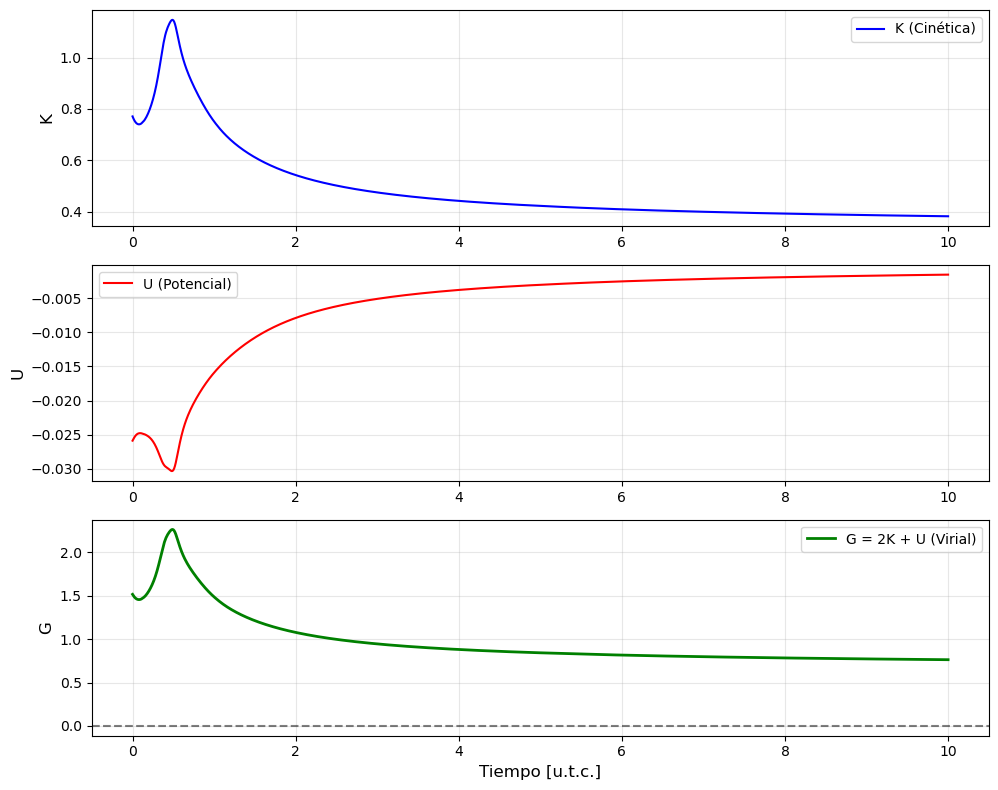

Energía total inicial: E = 0.745117
Energía total final: E = 0.380662
Variación relativa: 48.9125%


In [39]:
# Calcular energías para todos los pasos de tiempo
Ks = []
Us = []
Gs = []

for k in range(rps.shape[1]):
    K = 0.5 * np.sum(masas[:, None] * vps[:, k, :]**2)
    
    U = 0.0
    for i in range(N):
        for j in range(i + 1, N):
            rij = np.linalg.norm(rps[i, k] - rps[j, k])
            U += -G * masas[i] * masas[j] / rij
    
    G_virial = 2 * K + U
    
    Ks.append(K)
    Us.append(U)
    Gs.append(G_virial)

Ks = np.array(Ks)
Us = np.array(Us)
Gs = np.array(Gs)
Es_total = Ks + Us

# Tiempo
ts = np.linspace(0, T, rps.shape[1])

# Gráfico
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].plot(ts, Ks, label='K (Cinética)', color='blue')
axes[0].set_ylabel('K', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts, Us, label='U (Potencial)', color='red')
axes[1].set_ylabel('U', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(ts, Gs, label='G = 2K + U (Virial)', color='green', linewidth=2)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Tiempo [u.t.c.]', fontsize=12)
axes[2].set_ylabel('G', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Energía total inicial: E = {Es_total[0]:.6f}')
print(f'Energía total final: E = {Es_total[-1]:.6f}')
print(f'Variación relativa: {abs(Es_total[-1] - Es_total[0]) / abs(Es_total[0]) * 100:.4f}%')

## Tiempo de cruce y tiempo de relajación

Calcula el tiempo de cruce y el tiempo de relajación del sistema. Compara los valores observados con el comportamiento del virial escalar y comenta.

In [40]:
# Calcular el tiempo de cruce dinámico
# El tiempo de cruce es el tiempo típico para que una partícula atraviese el sistema

# Radio medio del sistema
R_medio = np.mean(np.linalg.norm(rps[:, 0, :], axis=1))

# Velocidad dispersión media (desviación estándar de velocidades)
v_disp = np.std(vps[:, 0, :])

# Tiempo de cruce dinámico
t_cruce = R_medio / v_disp

print(f"Radio medio del sistema: R = {R_medio:.4f} u.c.")
print(f"Dispersión de velocidades: σ_v = {v_disp:.4f} u.c./u.t.c.")
print(f"Tiempo de cruce: t_cruce = {t_cruce:.4f} u.t.c.")

# Tiempo de relajación (escala de Crossing time * N)
# Aproximación: t_relax ~ N / ln(N) * t_cruce
t_relax = (N / np.log(N)) * t_cruce

print(f"\nTiempo de relajación: t_relax ≈ {t_relax:.4f} u.t.c.")
print(f"Razón t_relax / t_cruce = {t_relax / t_cruce:.2f}")

# Analizar el comportamiento del virial escalar
print(f"\n--- Análisis del Virial Escalar ---")
print(f"G inicial: {Gs[0]:.6f}")
print(f"G final: {Gs[-1]:.6f}")
print(f"Variación de G: {abs(Gs[-1] - Gs[0]):.6f}")

# Tiempo de simulación
T_sim = ts[-1]
print(f"\nTiempo de simulación: T = {T_sim:.2f} u.t.c.")
print(f"Comparación: T / t_cruce = {T_sim / t_cruce:.2f}")
print(f"Comparación: T / t_relax = {T_sim / t_relax:.4f}")

# Comentario
print(f"\n--- COMENTARIO ---")
if T_sim < t_relax:
    print(f"La simulación es corta: T < t_relax")
    print(f"El sistema aún no ha relajado, por lo que el virial escalar")
    print(f"muestra oscilaciones y no ha alcanzado equilibrio.")
else:
    print(f"La simulación es larga: T > t_relax")
    print(f"El sistema debería haber relajado.")

Radio medio del sistema: R = 0.7662 u.c.
Dispersión de velocidades: σ_v = 0.9384 u.c./u.t.c.
Tiempo de cruce: t_cruce = 0.8166 u.t.c.

Tiempo de relajación: t_relax ≈ 5.4516 u.t.c.
Razón t_relax / t_cruce = 6.68

--- Análisis del Virial Escalar ---
G inicial: 1.516114
G final: 0.762877
Variación de G: 0.753237

Tiempo de simulación: T = 10.00 u.t.c.
Comparación: T / t_cruce = 12.25
Comparación: T / t_relax = 1.8343

--- COMENTARIO ---
La simulación es larga: T > t_relax
El sistema debería haber relajado.


Aumenta el número de partículas y observa los cambios.

In [ ]:
# Aumentar el número de partículas
N_new = 100

np.random.seed(1)

M = 1.0   # masa central
m_new = 0.001  # masa de cada partícula ligera

# Parámetros
N_ligeras_new = N_new - 1
sigma_v_frac = 0.005

# Masas (central + ligeras)
masas_new = np.concatenate(([M], np.full(N_ligeras_new, m_new)))

# Posiciones iniciales en un disco fino
Rmin, Rmax = 1, 5
rcoords_new = np.sqrt(np.random.uniform(Rmin**2, Rmax**2, N_ligeras_new))
phis_new = np.random.uniform(0, 2*np.pi, N_ligeras_new)

rinis_new = np.vstack([
    np.array([[0.0, 0.0, 0.0]]),
    np.column_stack([
        rcoords_new * np.cos(phis_new), 
        rcoords_new * np.sin(phis_new), 
        np.zeros(N_ligeras_new)
    ])
])

# Velocidades tangenciales circulares
v_circ_new = np.sqrt(G * M / rcoords_new)
vx_new = -v_circ_new *
vy_new =


vinis_new

    np.column_stack(
])


VC
vinis_new -= VCM_new

# Simular


# Animar
anima_ncuerpos(masas_new, rps_new, T=10)rps_new, vps_new = simula_ncuerpos_rebound(masas_new, rinis_new, vinis_new, T=10, Nt=1000)M_new = np.average(vinis_new, axis=0, weights=masas_new)# Quitar deriva del centro de masa[vx_new, vy_new, vz_new])    np.array([[0.0, 0.0, 0.0]]), = np.vstack([vz_new = np.zeros(N_ligeras_new) v_circ_new * np.cos(phis_new) np.sin(phis_new)# Aumentar el número de partículas
N_new = 100

np.random.seed(1)

M = 1.0   # masa central
m_new = 0.001  # masa de cada partícula ligera

# Parámetros
N_ligeras_new = N_new - 1
sigma_v_frac = 0.005

# Masas (central + ligeras)
masas_new = np.concatenate(([M], np.full(N_ligeras_new, m_new)))

# Posiciones iniciales en un disco fino
Rmin, Rmax = 1, 5
rcoords_new = np.sqrt(np.random.uniform(Rmin**2, Rmax**2, N_ligeras_new))
phis_new = np.random.uniform(0, 2*np.pi, N_ligeras_new)

rinis_new = np.vstack([
    np.array([[0.0, 0.0, 0.0]]),
    np.column_stack([
        rcoords_new * np.cos(phis_new), 
        rcoords_new * np.sin(phis_new), 
        np.zeros(N_ligeras_new)
    ])
])

# Velocidades tangenciales circulares
v_circ_new = np.sqrt(G * M / rcoords_new)
vx_new = -v_circ_new *
# Animar

rps_new, vps_new = simula_ncuerpos_rebound(masas_new, rinis_new, vinis_new, T=10, Nt=1000)
# Simular

vinis_new -= VCM_new
VCM_new = np.average(vinis_new, axis=0, weights=masas_new)
# Quitar deriva del centro de masa

])
    np.column_stack([vx_new, vy_new, vz_new])
    np.array([[0.0, 0.0, 0.0]]),
vinis_new = np.vstack([

vz_new = np.zeros(N_ligeras_new)
vy_new = v_circ_new * np.cos(phis_new) np.sin(phis_new)# Aumentar el número de partículas
N_new = 100

np.random.seed(1)

M = 1.0   # masa central
m_new = 0.001  # masa de cada partícula ligera

# Parámetros
N_ligeras_new = N_new - 1
sigma_v_frac = 0.005

# Masas (central + ligeras)
masas_new = np.concatenate(([M], np.full(N_ligeras_new, m_new)))

# Posiciones iniciales en un disco fino
Rmin, Rmax = 1, 5
rcoords_new = np.sqrt(np.random.uniform(Rmin**2, Rmax**2, N_ligeras_new))
phis_new = np.random.uniform(0, 2*np.pi, N_ligeras_new)

rinis_new = np.vstack([
    np.array([[0.0, 0.0, 0.0]]),
    np.column_stack([
        rcoords_new * np.cos(phis_new), 
        rcoords_new * np.sin(phis_new), 
        np.zeros(N_ligeras_new)
    ])
])

# Velocidades tangenciales circulares
v_circ_new = np.sqrt(G * M / rcoords_new)
vx_new = -v_circ_new * np.sin(phis_new)

## Un sistema no colisional

Hay sistemas de N-cuerpos en los que el potencial gravitacional varía muy poco espacialmente. A estos sistemas se los conoce como sistemas no colisionales. Abajo generamos las condiciones iniciales de un sistema gravitacional no colisional:

In [41]:
np.random.seed(1)

N = 20 
M = 1.0   # masa central
m = 0.001  # masa de cada partícula ligera (m << M)

# Parámetros
N_ligeras = N - 1  # número de partículas ligeras
sigma_v_frac = 0.005 # dispersión fraccional de velocidad

# Masas (central + ligeras)
masas = np.concatenate(([M], np.full(N_ligeras, m)))

# Posiciones iniciales en un disco fino (z=0) con densidad superficial ~ uniforme
Rmin, Rmax = 1, 5
rcoords = np.sqrt(np.random.uniform(Rmin**2, Rmax**2, N_ligeras))
phis = np.random.uniform(0, 2*np.pi, N_ligeras)

rinis = np.vstack([
    np.array([[0.0, 0.0, 0.0]]),
    np.column_stack([
        rcoords * np.cos(phis), 
        rcoords * np.sin(phis), 
        np.zeros(N_ligeras)
    ])
])

# Velocidades tangenciales circulares respecto a la masa central
v_circ = np.sqrt(G * M / rcoords)
vx = -v_circ * np.sin(phis)
vy =  v_circ * np.cos(phis)
vz = np.zeros(N_ligeras)

# Velocidades iniciales
vinis = np.vstack([
    np.array([[0.0, 0.0, 0.0]]),
    np.column_stack([vx, vy, vz])
])

# Quitar deriva del centro de masa
VCM = np.average(vinis, axis=0, weights=masas)
vinis -= VCM

Simulemos y animemos:

In [42]:
simula_ncuerpos_rebound(masas, rinis, vinis, T=10, Nt=1000)
anima_ncuerpos(masas, rps, T=10)

Haz un gráfico de las energías y del virial escalar:

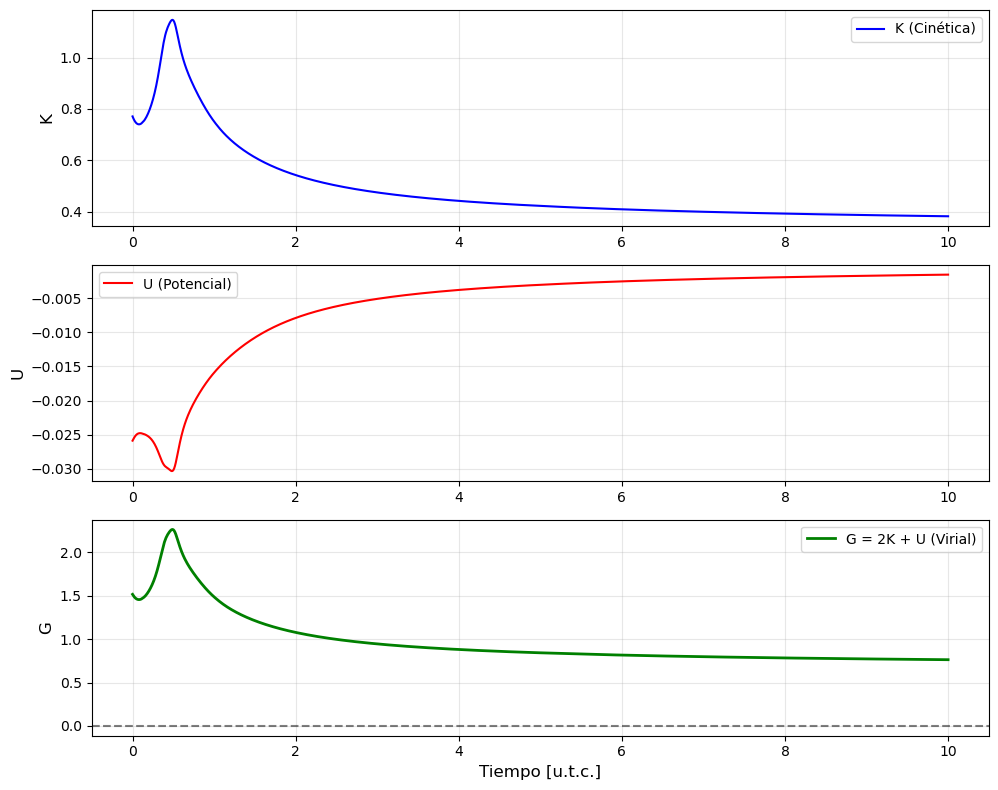

Energía total inicial: E = 0.745117
Energía total final: E = 0.380662
Variación relativa: 48.9125%


In [43]:
# Calcular energías para todos los pasos de tiempo
Ks = []
Us = []
Gs = []

for k in range(rps.shape[1]):
    K = 0.5 * np.sum(masas[:, None] * vps[:, k, :]**2)
    
    U = 0.0
    for i in range(N):
        for j in range(i + 1, N):
            rij = np.linalg.norm(rps[i, k] - rps[j, k])
            U += -G * masas[i] * masas[j] / rij
    
    G_virial = 2 * K + U
    
    Ks.append(K)
    Us.append(U)
    Gs.append(G_virial)

Ks = np.array(Ks)
Us = np.array(Us)
Gs = np.array(Gs)
Es_total = Ks + Us

# Tiempo
ts_plot = np.linspace(0, 10, rps.shape[1])

# Gráfico
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].plot(ts_plot, Ks, label='K (Cinética)', color='blue')
axes[0].set_ylabel('K', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts_plot, Us, label='U (Potencial)', color='red')
axes[1].set_ylabel('U', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(ts_plot, Gs, label='G = 2K + U (Virial)', color='green', linewidth=2)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Tiempo [u.t.c.]', fontsize=12)
axes[2].set_ylabel('G', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Energía total inicial: E = {Es_total[0]:.6f}')
print(f'Energía total final: E = {Es_total[-1]:.6f}')
print(f'Variación relativa: {abs(Es_total[-1] - Es_total[0]) / abs(Es_total[0]) * 100:.4f}%')